In [1]:
from module import plot_ensemble, HumanForestModel, plot_collapse_ci
import matplotlib.pyplot as plt
import numpy as np

# Define parameters

In [2]:
# Define parameters [Sumba case]
dt = 1/12               # year
r  = 0.01               # years**{-1}
r_ = 0.001              # years**{-1}
a0 = 0.14 / 20 / 686e3      # years**{-1}

Rc = 10_910                # km**2
N0 = 780_000
R0 = 5_023
Nc = 500 * Rc #1.2 * N0 #Rc * 100
beta = Nc/Rc
# gamma = 0.5 * r_             # years**{-1}
t_bounds = [2020, 2200]

# Simulate with bootstrap

In [3]:
# Define gamma variation
gamma_list = np.arange(0, 0.06, 0.01)
gamma_list_disp = np.arange(0, 0.06, 0.01)

# Define ensemble
n_boot = 1_000

N_ens_list, R_ens_list, clps_ens_list = [], [], []
for gamma in gamma_list:

    # Construct model
    model = HumanForestModel(dt, r, r_, a0, beta, Rc, gamma, N0, R0, t_bounds)
    
    # Simulate over different resampling of ENSO
    N_ens, R_ens, clps_ens = [], [], []
    for _ in range (n_boot):
        enso_list = model.generate_enso(enso_file='../data/nino34r_det.csv')
        N_list, R_list, t_list, t_clps = model.solve(enso_list)
        N_ens.append(N_list)
        R_ens.append(R_list)
        clps_ens.append(t_clps)
    
    # Save ensemble
    N_ens_list.append(N_ens)
    R_ens_list.append(R_ens)
    clps_ens_list.append(clps_ens)

# Deliverables

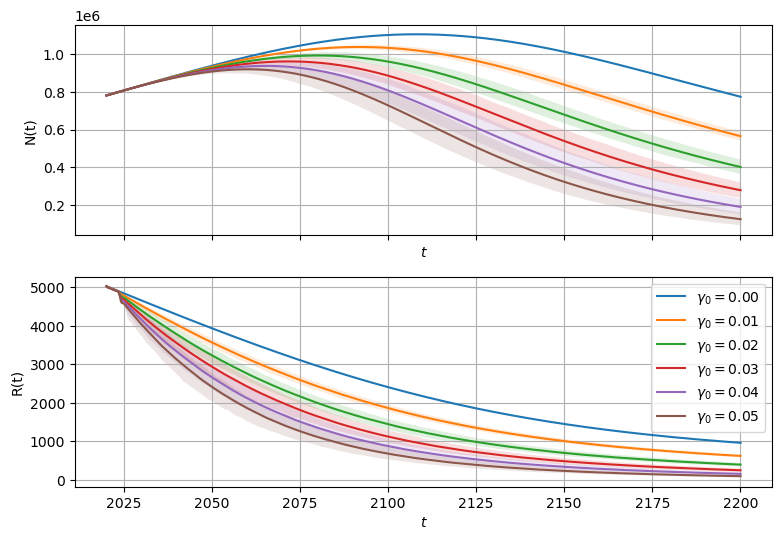

In [4]:
# Initialize plot
fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for gamma, N_ens, R_ens in zip(gamma_list, N_ens_list, R_ens_list):
    # Plot
    plot_ensemble(t_list, N_ens, axs[0], label=rf'$\gamma_0={gamma:.2f}$')
    axs[0].set_ylabel(r'N(t)'); axs[0].set_xlabel(r'$t$')

    plot_ensemble(t_list, R_ens, axs[1],label=rf'$\gamma_0={gamma:.2f}$')
    axs[1].set_ylabel(r'R(t)'); axs[1].set_xlabel(r'$t$')

axs[1].legend()
axs[0].grid(); axs[1].grid()
plt.savefig('../output/timeseries.png')
plt.show()

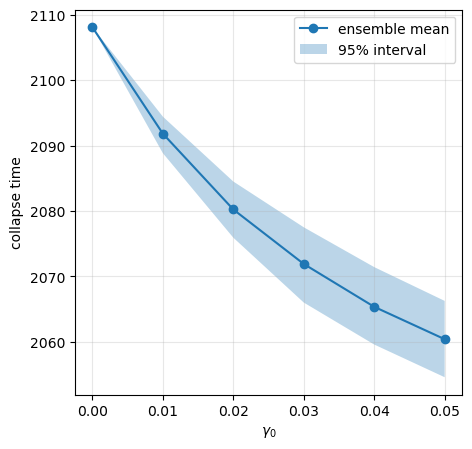

In [5]:
fig, ax = plt.subplots(figsize=(5,5))
plot_collapse_ci(ax, gamma_list, clps_ens_list, outfile='../output/collapse_time.csv')
plt.savefig('../output/collapse_time.png')
plt.show()